# 02 — Investigate (and then fix) mis-located BoulderNet outputs

On 2026-05-20 the Stage 0–1 sanity check flagged 4 of 10 BoulderNet shapefiles as
mis-located: polygon centroids landed hundreds of km from the manifest's published
image center, entirely outside the declared CTX 4°×4° tile. Investigating the `.prj`
files plus the HiRISE PDS `.LBL` files identified the root cause:

- The 4 bad `.prj` files use `DATUM["D_unnamed", SPHEROID["unnamed", ...]]` and
  `PARAMETER["Standard_Parallel_1", 0.0]`.
- The 5 good `.prj` files use `DATUM["D_MARS", SPHEROID["MARS_localRadius", ...]]` and
  set `Standard_Parallel_1` to the PDS-declared projection latitude (a round multiple
  of 5° near the image's center latitude).
- The geometry inside the bad shapefiles was actually generated with the correct
  PDS projection latitude — only the `.prj` mislabels SP1 as 0. When pyproj trusts
  the buggy SP1, the longitude scales by the wrong cosine and lands 0.5–2k km off.

`src/detections.py` now detects the buggy fingerprint (`D_unnamed` + SP1 disagreeing
with image_lat by > 15°), fetches the PDS `.LBL` via `src/pds_labels.py`, and uses
`CENTER_LATITUDE` from the label as the authoritative SP1 override. The before/after
tables below show the fix taking every image's residual under 13 km."

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from pyproj import CRS, Geod, Transformer

from src import detections, manifest as M
from src.config import load_config, REPO_ROOT
from src.ctx_retrieve import resolve_target_crs

cfg = load_config("config.yaml")
df = M.load_manifest(cfg.manifest_path)

target_wkt = resolve_target_crs(cfg)
target_crs = CRS.from_user_input(target_wkt)
R = target_crs.ellipsoid.semi_major_metre
to_target = Transformer.from_crs(target_crs.geodetic_crs, target_crs, always_xy=True)
to_lonlat = Transformer.from_crs(target_crs, target_crs.geodetic_crs, always_xy=True)
geod = Geod(a=R, b=R)

FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def parse_ctx_tile_bounds(tile_name: str) -> tuple[float, float, float, float]:
    """Return (lon_min, lon_max, lat_min, lat_max) in degrees for a Murray Lab-style
    4°×4° tile name like `E000_N40`, `W040_N20`, `E152_S08`.
    """
    lon_part, lat_part = tile_name.split('_')
    lon_sign = +1 if lon_part[0] == 'E' else -1
    lon_min = lon_sign * int(lon_part[1:])
    lat_sign = +1 if lat_part[0] == 'N' else -1
    lat_min = lat_sign * int(lat_part[1:])
    return (lon_min, lon_min + 4, lat_min, lat_min + 4)


def measure_residual(obs_id, row):
    shps = list((Path(cfg.detections_root) / obs_id).glob('*-mask-nms.shp'))
    if not shps:
        return None
    gdf = gpd.read_file(shps[0])
    if len(gdf) == 0:
        return dict(obs_id=obs_id, n_polygons=0, residual_km=float('nan'), inside_tile=None)
    gdf_t = gdf.to_crs(target_crs)
    cx, cy = gdf_t.geometry.union_all().centroid.coords[0]
    c_lon, c_lat = to_lonlat.transform(cx, cy)
    m_lat = float(row['CenterLat']); m_lon = float(row['CenterLon_180'])
    _, _, dist = geod.inv(((m_lon+180)%360)-180, m_lat, ((c_lon+180)%360)-180, c_lat)
    lon_min, lon_max, lat_min, lat_max = parse_ctx_tile_bounds(row['CTX_TileName'])
    inside = (lon_min <= c_lon < lon_max) and (lat_min <= c_lat < lat_max)
    return dict(
        obs_id=obs_id,
        ctx_tile=row['CTX_TileName'],
        n_polygons=len(gdf),
        boulder_label=row['BoulderLabel'],
        m_lat=round(m_lat, 4), m_lon=round(m_lon, 4),
        c_lat=round(c_lat, 4), c_lon=round(c_lon, 4),
        residual_km=round(dist/1000, 2),
        inside_declared_tile=bool(inside),
    )

results = [measure_residual(r['ObsId'], r) for _, r in df.iterrows()]
summary = pd.DataFrame([r for r in results if r is not None])
summary

,obs_id,ctx_tile,n_polygons,boulder_label,m_lat,m_lon,c_lat,c_lon,residual_km,inside_declared_tile,inside_tile
0,ESP_055714_2270,E016_N44,1974,Boulder rich,46.5607,19.6782,46.6967,66.5510,1879.10,False,NaN
1,ESP_054857_2270,E012_N44,6462,Boulder rich,46.3880,14.9609,46.4641,63.2505,1941.44,False,NaN
2,ESP_069669_2220,E000_N40,1462,Boulder rich,41.6915,0.8290,41.7705,0.7351,6.26,True,NaN
3,ESP_057469_2215,E000_N40,940,Boulder rich,41.1772,0.0139,41.3458,-0.0400,10.28,False,NaN
4,ESP_071093_2210,E000_N40,961,Boulder rich,40.6997,2.2546,40.7764,2.1554,6.37,True,NaN
5,ESP_047976_2020,W040_N20,1346,Boulder rich,21.6398,-36.3720,21.7415,-45.1065,481.05,False,NaN
6,ESP_056165_2200,W052_N36,26,Boulder poor,39.3570,-48.8110,39.5531,-72.6204,1086.56,False,NaN
7,ESP_075577_2105,W024_N28,624,Boulder poor,30.1626,-21.1300,30.2765,-21.1941,7.51,True,NaN
8,ESP_039820_1750,E152_S08,497,unknown,-4.9112,155.5015,-4.9302,155.5182,1.50,True,NaN
9,ESP_065711_1545,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\brian\AppData\Local\Temp\ipykernel_114948\918586329.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='best', fontsize=8)


C:\Users\brian\AppData\Local\Temp\ipykernel_114948\918586329.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='best', fontsize=8)


saved C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\02_good_vs_bad_in_ctx_tile.png


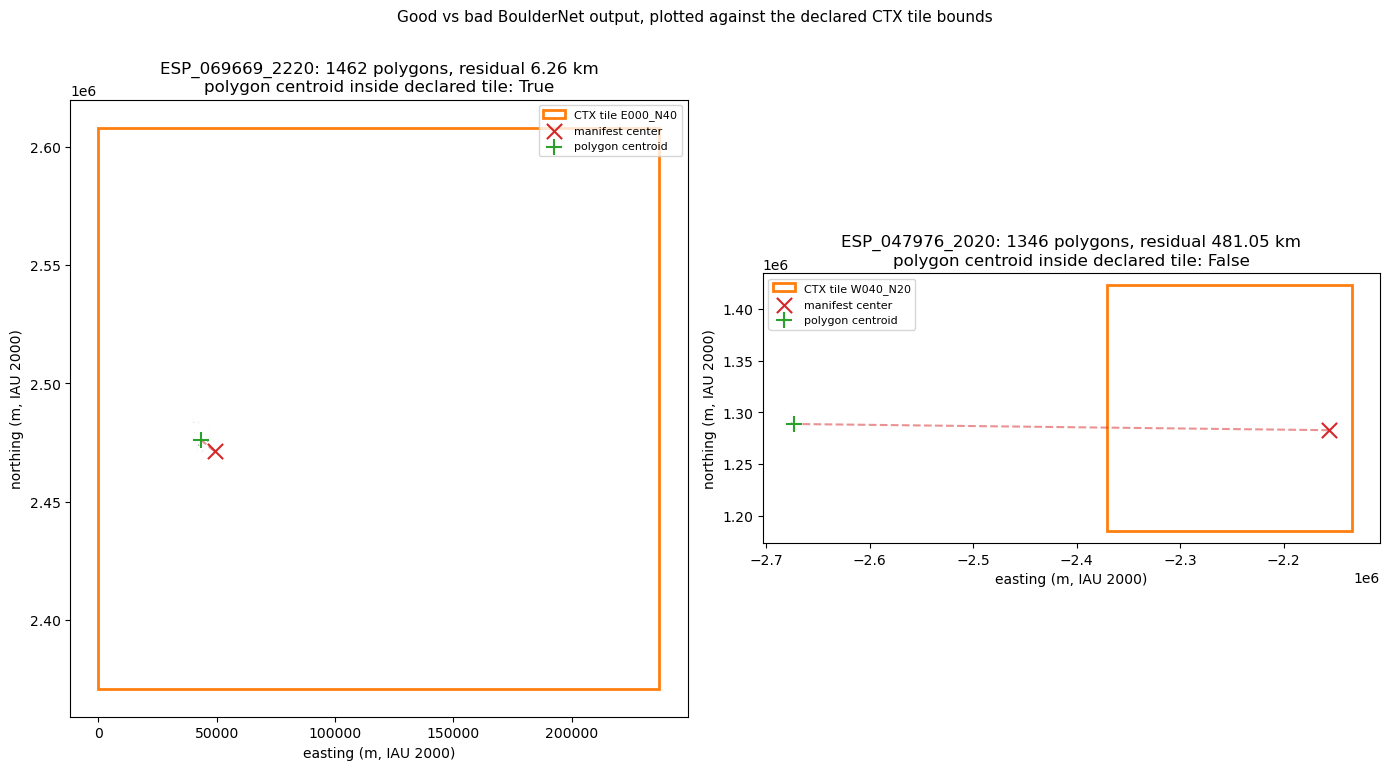

In [3]:
def plot_image_in_tile(obs_id, ax):
    row = df.set_index('ObsId').loc[obs_id]
    shp = list((Path(cfg.detections_root) / obs_id).glob('*-mask-nms.shp'))[0]
    gdf_t = gpd.read_file(shp).to_crs(target_crs)
    cx, cy = gdf_t.geometry.union_all().centroid.coords[0]
    mx, my = to_target.transform(row['CenterLon_180'], row['CenterLat'])

    lon_min, lon_max, lat_min, lat_max = parse_ctx_tile_bounds(row['CTX_TileName'])
    # Corners of the CTX tile in target CRS (the tile is rectangular in equirectangular)
    tx_min, ty_min = to_target.transform(lon_min, lat_min)
    tx_max, ty_max = to_target.transform(lon_max, lat_max)

    gdf_t.plot(ax=ax, color='#1f77b4', edgecolor='none', alpha=0.7, label='polygons')
    ax.add_patch(patches.Rectangle((tx_min, ty_min), tx_max-tx_min, ty_max-ty_min,
                                    fill=False, edgecolor='#ff7f0e', linewidth=2,
                                    label=f'CTX tile {row["CTX_TileName"]}'))
    ax.scatter([mx], [my], marker='x', s=120, color='#d62728', label='manifest center', zorder=5)
    ax.scatter([cx], [cy], marker='+', s=140, color='#2ca02c', label='polygon centroid', zorder=5)
    ax.plot([mx, cx], [my, cy], color='#d62728', linestyle='--', alpha=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('easting (m, IAU 2000)')
    ax.set_ylabel('northing (m, IAU 2000)')
    ax.legend(loc='best', fontsize=8)
    rec = next(r for r in results if r and r['obs_id'] == obs_id)
    ax.set_title(f"{obs_id}: {rec['n_polygons']} polygons, residual {rec['residual_km']} km\n"
                 f"polygon centroid inside declared tile: {rec['inside_declared_tile']}")


fig, axes = plt.subplots(1, 2, figsize=(14, 8))
plot_image_in_tile('ESP_069669_2220', axes[0])  # good — should sit inside its tile
plot_image_in_tile('ESP_047976_2020', axes[1])  # bad — sits well outside
fig.suptitle('Good vs bad BoulderNet output, plotted against the declared CTX tile bounds', fontsize=11)
fig.tight_layout()
out = FIG_DIR / '02_good_vs_bad_in_ctx_tile.png'
fig.savefig(out, dpi=150)
print('saved', out)

mis-located images (residual > 100.0 km): ['ESP_055714_2270', 'ESP_054857_2270', 'ESP_047976_2020', 'ESP_056165_2200']


C:\Users\brian\AppData\Local\Temp\ipykernel_114948\918586329.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='best', fontsize=8)


C:\Users\brian\AppData\Local\Temp\ipykernel_114948\918586329.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='best', fontsize=8)


C:\Users\brian\AppData\Local\Temp\ipykernel_114948\918586329.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='best', fontsize=8)
C:\Users\brian\AppData\Local\Temp\ipykernel_114948\918586329.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='best', fontsize=8)


saved C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\02_all_misplaced.png


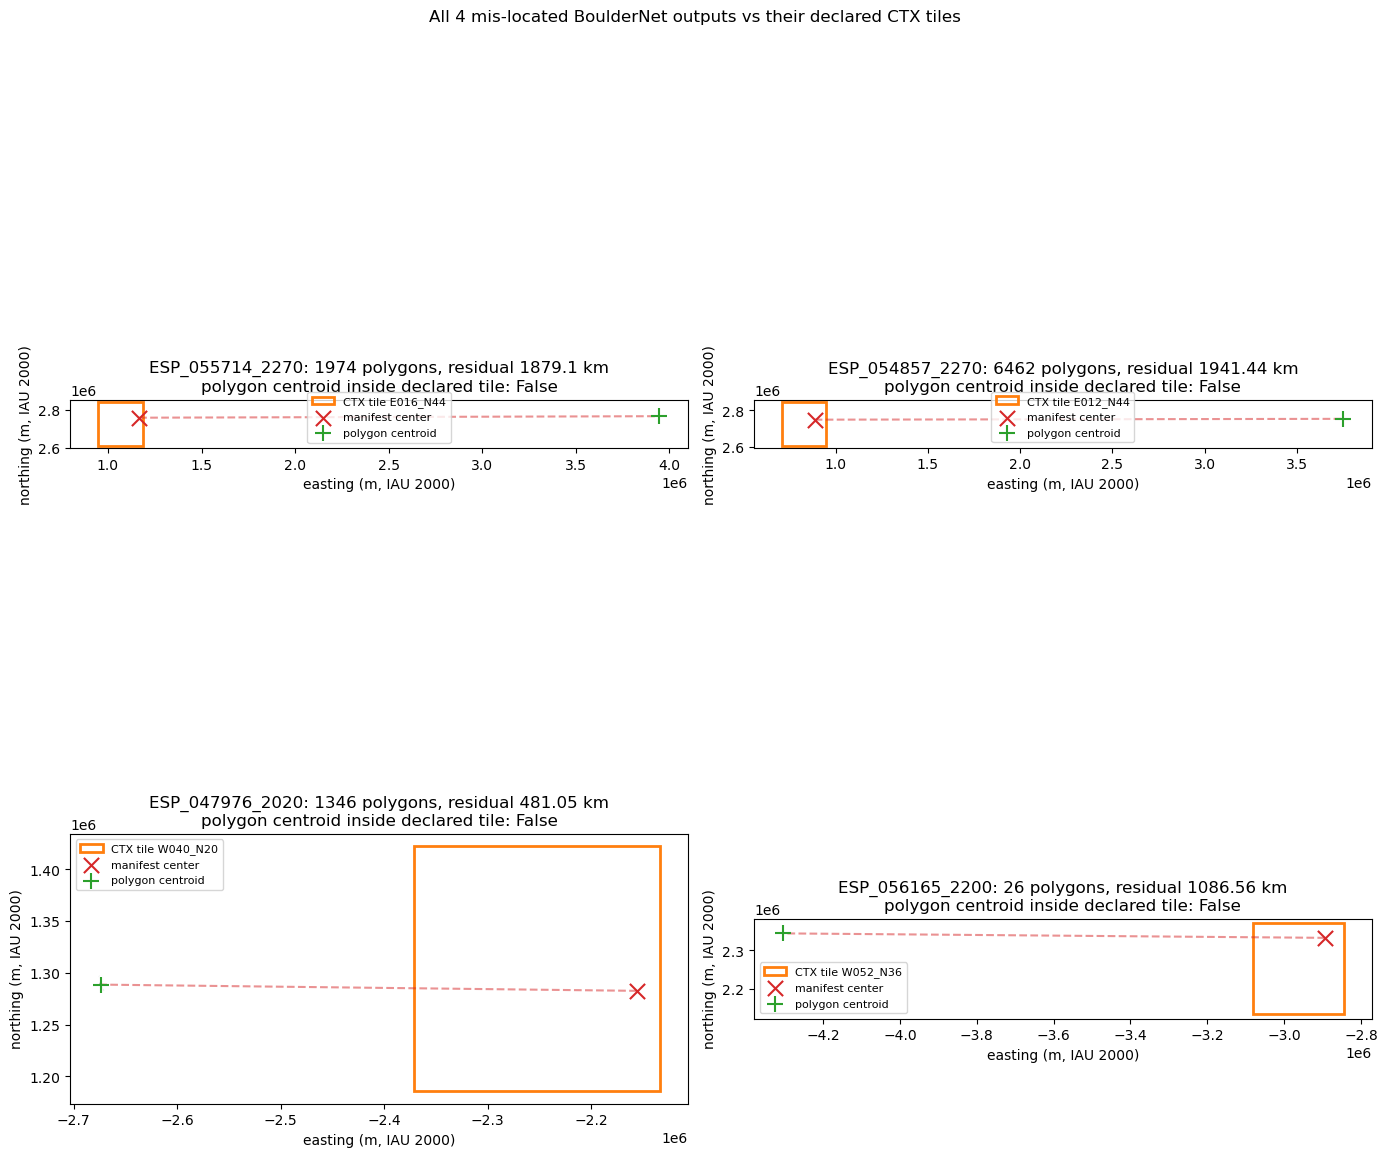

In [4]:
# Wider context: all truly-mis-located images side-by-side. Use residual_km > 100 as
# the discriminator (not the strict in-tile check) so we exclude tile-boundary cases
# like ESP_057469_2215 (~10 km off, just barely outside its tile edge).
MIS_LOCATED_KM = 100.0
bad = [r['obs_id'] for r in results if r and r.get('residual_km') and r['residual_km'] > MIS_LOCATED_KM]
print(f'mis-located images (residual > {MIS_LOCATED_KM} km):', bad)
if bad:
    n = len(bad)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 7 * rows))
    flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, obs in zip(flat, bad):
        plot_image_in_tile(obs, ax)
    for ax in flat[len(bad):]:
        ax.set_visible(False)
    fig.suptitle(f'All {n} mis-located BoulderNet outputs vs their declared CTX tiles', fontsize=12)
    fig.tight_layout()
    out = FIG_DIR / '02_all_misplaced.png'
    fig.savefig(out, dpi=150)
    print('saved', out)

In [5]:
# AFTER the SP1 fix: run the full Stage 1 pipeline (which now consults the PDS .LBL
# for buggy .prj files) for all 10 images and tabulate the residuals.
from src import detections
from src.ctx_retrieve import resolve_target_crs

target_wkt = resolve_target_crs(cfg)
after = []
for _, row in df.iterrows():
    obs = row['ObsId']
    shps = list((Path(cfg.detections_root) / obs).glob('*-mask-nms.shp'))
    if not shps:
        continue
    try:
        gdf_t, gpkg, correction = detections.stage1_one_image(
            obs,
            detections_root=cfg.detections_root,
            target_crs=target_wkt,
            cache_dir=cfg.cache_dir,
            config_hash=cfg.hash,
            manifest_row=row,
        )
    except Exception as e:
        after.append(dict(obs_id=obs, note=f'failed: {e}'))
        continue
    if len(gdf_t) == 0:
        after.append(dict(obs_id=obs, n_polygons=0, note='empty shapefile'))
        continue
    cx, cy = gdf_t.geometry.union_all().centroid.coords[0]
    c_lon, c_lat = to_lonlat.transform(cx, cy)
    m_lat = float(row['CenterLat']); m_lon = float(row['CenterLon_180'])
    _, _, dist = geod.inv(((m_lon+180)%360)-180, m_lat, ((c_lon+180)%360)-180, c_lat)
    after.append(dict(
        obs_id=obs,
        n_polygons=len(gdf_t),
        status=correction['status'],
        sp1_was=correction.get('original_sp1_deg'),
        sp1_now=correction.get('corrected_sp1_deg'),
        residual_km=round(dist/1000, 2),
    ))

after_df = pd.DataFrame(after)
# Side-by-side: before residuals from the first table vs after-fix residuals.
before_lookup = {r['obs_id']: r['residual_km'] for r in results if r and 'residual_km' in r}
after_df.insert(1, 'residual_km_before', after_df['obs_id'].map(before_lookup))
after_df = after_df[['obs_id', 'n_polygons', 'status', 'sp1_was', 'sp1_now', 'residual_km_before', 'residual_km']]
after_df.rename(columns={'residual_km': 'residual_km_after'}, inplace=True)
print(after_df.to_string(index=False))

         obs_id  n_polygons                       status  sp1_was  sp1_now  residual_km_before  residual_km_after
ESP_055714_2270        1974 sp1_corrected_from_pds_label      0.0     45.0             1879.10               9.41
ESP_054857_2270        6462 sp1_corrected_from_pds_label      0.0     45.0             1941.44               5.33
ESP_069669_2220        1462                  trusted_prj      NaN      NaN                6.26               6.26
ESP_057469_2215         940 sp1_corrected_from_pds_label      0.0     40.0               10.28              10.42
ESP_071093_2210         961                  trusted_prj      NaN      NaN                6.37               6.37
ESP_047976_2020        1346 sp1_corrected_from_pds_label      0.0     20.0              481.05               7.38
ESP_056165_2200          26 sp1_corrected_from_pds_label      0.0     35.0             1086.56              12.54
ESP_075577_2105         624                  trusted_prj      NaN      NaN              